# Learning Lorenz System Using Different Methods
This notebook implements the fourth-order Runge-Kutta (RK4) and other three methods to simulate the Lorenz system and generate reference trajectories.
1. RK4 (Numerical)
2. Neural Network (Regression)
3. Neural ODE
4. PINN (Two Loss Stages, Data Loss + Physical Loss)

## 1. Numerical Simulation via RK4

RK4 (fourth-order Runge-Kutta) is used to generate the ground truth trajectory 
of the Lorenz system. At each time step, four slope estimates are computed and 
combined into a weighted average, giving a more accurate result than simple 
Euler integration.

The resulting trajectory serves as the reference for all subsequent ML methods. 
Parameters used: σ = 10, ρ = 28, β = 8/3, initial condition (1, 1, 1), 
t ∈ [0, 50], Δt = 0.01.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


## 1.1. Define the Lorenz System

In [2]:
# parameters
sigma = 10.0
rho   = 28.0
beta  = 8.0 / 3.0

def lorenz(u):
    x, y, z = u
    return np.array([
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ])

# rk4 single step
def rk4_step(f, u, dt):
    k1 = f(u)
    k2 = f(u + dt/2 * k1)
    k3 = f(u + dt/2 * k2)
    k4 = f(u + dt   * k3)
    return u + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

# run simulation
def simulate(u0, t_span, dt):
    steps = int((t_span[1] - t_span[0]) / dt)
    t = np.linspace(t_span[0], t_span[1], steps)
    traj = np.zeros((steps, 3))
    traj[0] = u0
    for i in range(1, steps):
        traj[i] = rk4_step(lorenz, traj[i-1], dt)
    return t, traj

In [3]:
u0 = np.array([1.0, 1.0, 1.0])
dt = 0.01
t_span = (0, 50)

t, traj = simulate(u0, t_span, dt)
x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]



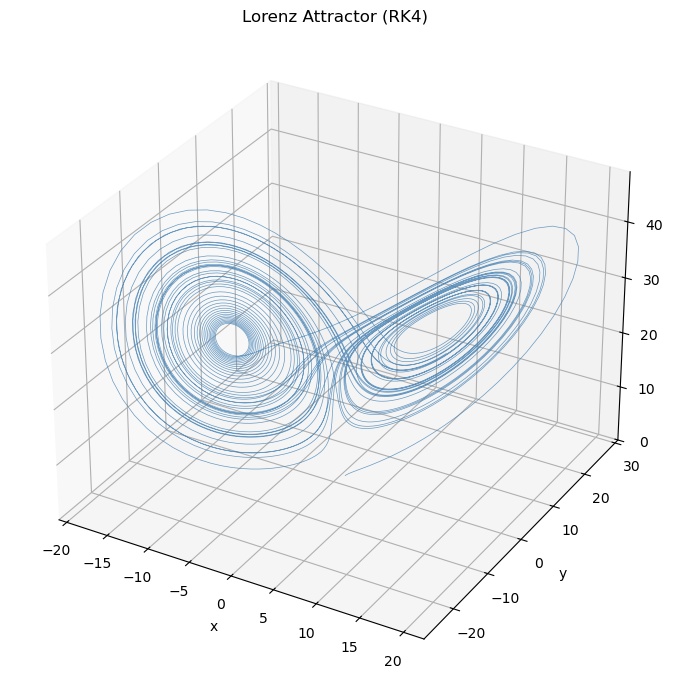

In [4]:
# 3d attractor
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, lw=0.5, alpha=0.8, color='steelblue')
ax.set_title('Lorenz Attractor (RK4)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.tight_layout()
plt.savefig('lorenz_attractor_3d.png', dpi=150)
plt.show()




In [5]:
# store the data here, for model training
np.save('lorenz_data.npy', np.column_stack([t, traj]))

So the plot is as follow:
1. X is the intencity of convection.
    "Positive": Convectino is moving in the same direction
    "Negative": Convection is moving in reverse direction as comparison to positive
    "Bouncing back & forth": Direction is changing

2. Y is the horizontal temperature differences: It bounces back & forth since they affect each other

3. Z is the vertical temperature differences: It is always POSITIVE (It is a physical value which is always >= 0, the range is approximately between: 5 < z < 45)

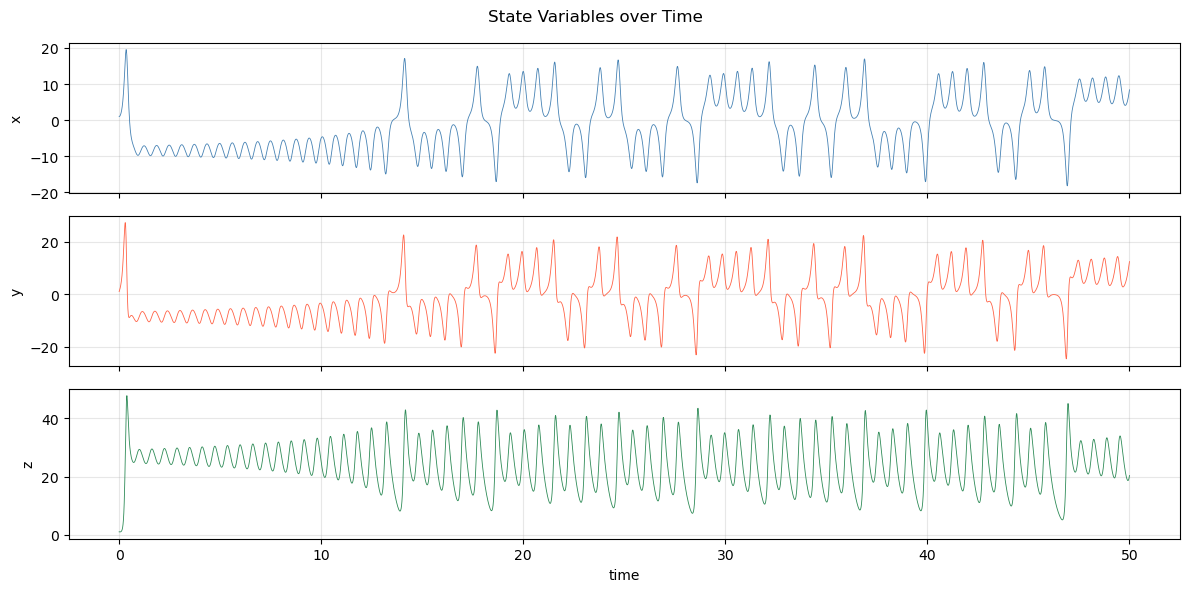

In [6]:
# x y z over time
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, label, color, d in zip(axes, ['x','y','z'], ['steelblue','tomato','seagreen'], [x,y,z]):
    ax.plot(t, d, lw=0.6, color=color)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('State Variables over Time')
plt.tight_layout()
plt.savefig('lorenz_timeseries.png', dpi=150)
plt.show()


Two simulations, basically identical starting points:

- Blue: starts at x = 1
- Red: starts at x = 1.00001

The difference is 0.00001 — basically nothing.

Look what happens — up until around t=20 the two lines are completely on top of each other, you can't even tell them apart. Then they start to split. By t=30 they're totally different, one going up while the other goes down.

This is the butterfly effect in action. The system is so sensitive that even a microscopic difference in where you start leads to completely different behavior later on. This is also why weather forecasts beyond a few days are basically useless — not because the computers aren't good enough, but because the atmosphere behaves the same way.

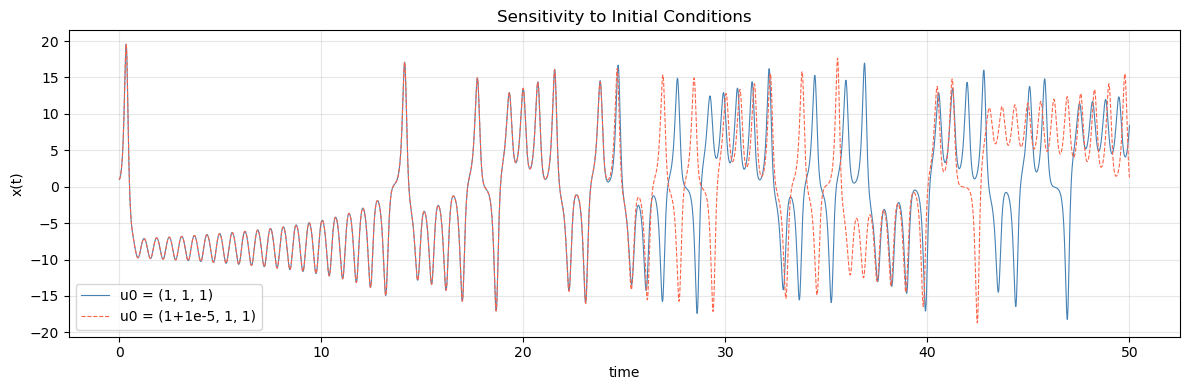

In [7]:

# sensitivity to initial conditions
_, traj2 = simulate(np.array([1.0 + 1e-5, 1.0, 1.0]), t_span, dt)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, x,          lw=0.8, color='steelblue', label='u0 = (1, 1, 1)')
ax.plot(t, traj2[:,0], lw=0.8, color='tomato', linestyle='--', label='u0 = (1+1e-5, 1, 1)')
ax.set_xlabel('time'); ax.set_ylabel('x(t)')
ax.set_title('Sensitivity to Initial Conditions')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lorenz_sensitivity.png', dpi=150)
plt.show()

## 2. Pure Neural Network (Data Driven): Regression （MLP）
A standard multilayer perceptron is trained directly on the RK4-generated data,
with no knowledge of the underlying physics. Two formulations are tested to
understand how problem framing affects performance.

In [8]:
import torch
import torch.nn as nn

## 2.1. Long-term Prediction: t → (x, y, z)

The first formulation attempts to map time $t$ directly to the system state $(x, y, z)$.
The intuition is straightforward — if we know the time, can we predict where the system is?

The answer is no. Because the Lorenz system is chaotic, the same value of $t$ does not 
uniquely determine the state. The network has no way to distinguish between different 
passes through the same region of phase space, so it collapses to predicting the mean 
of the training data. This experiment is kept as a contrast to show that problem 
framing matters more than model capacity.

epoch 0, loss 265.3763
epoch 100, loss 83.5254
epoch 200, loss 65.9745
epoch 300, loss 64.7021
epoch 400, loss 64.4838
epoch 500, loss 64.3126
epoch 600, loss 64.1785
epoch 700, loss 64.0602
epoch 800, loss 63.9528
epoch 900, loss 63.8555
epoch 1000, loss 63.7693
epoch 1100, loss 63.6953
epoch 1200, loss 63.6330
epoch 1300, loss 63.5819
epoch 1400, loss 63.5397
epoch 1500, loss 63.5047
epoch 1600, loss 63.4748
epoch 1700, loss 63.4488
epoch 1800, loss 63.4257
epoch 1900, loss 63.4047


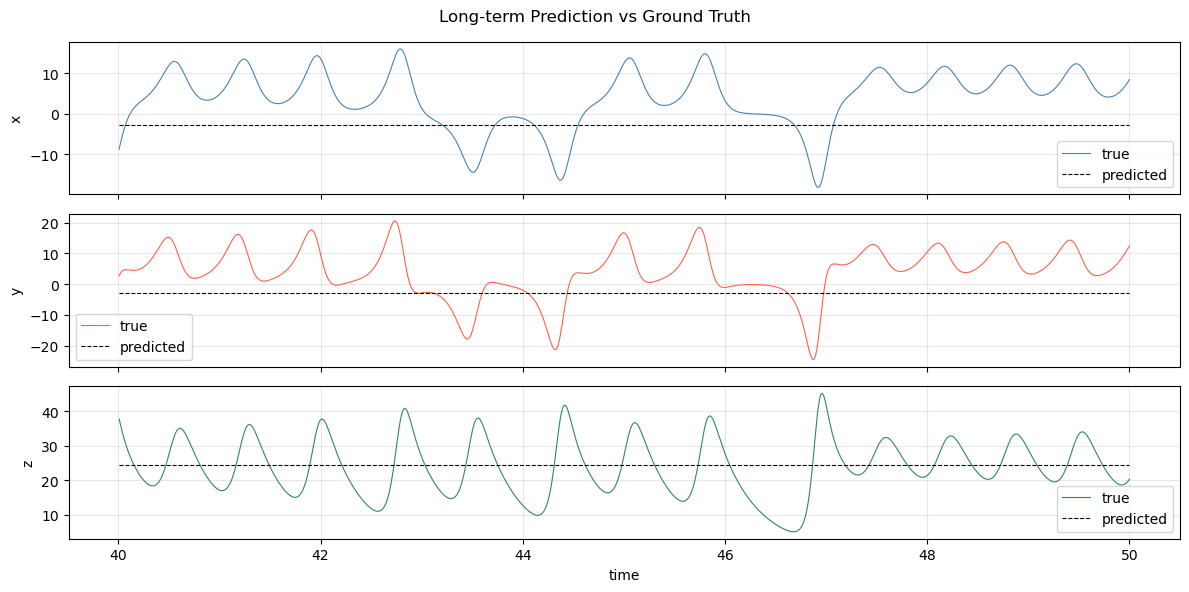

In [9]:
# long-term prediction: t -> (x, y, z)
data = np.load('lorenz_data.npy')
t    = data[:, 0].astype(np.float32)
traj = data[:, 1:].astype(np.float32)

split = int(len(t) * 0.8)
X_train = torch.tensor(t[:split]).unsqueeze(1)
y_train = torch.tensor(traj[:split])
X_test  = torch.tensor(t[split:]).unsqueeze(1)
y_test  = torch.tensor(traj[split:])

model_long = nn.Sequential(
    nn.Linear(1, 64), nn.Tanh(),
    nn.Linear(64, 256), nn.Tanh(),
    nn.Linear(256, 128), nn.Tanh(),
    nn.Linear(128, 3)
)

optimizer = torch.optim.Adam(model_long.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

for epoch in range(2000):
    pred = model_long(X_train)
    loss = loss_fn(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'epoch {epoch}, loss {loss.item():.4f}')

# plot
model_long.eval()
with torch.no_grad():
    pred_test = model_long(X_test).numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t[split:], y_test[:, i].numpy(), lw=0.8, color=color, label='true')
    axes[i].plot(t[split:], pred_test[:, i],      lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('Long-term Prediction vs Ground Truth')
plt.tight_layout()
plt.savefig('nn_longterm.png', dpi=150)
plt.show()

## 2.2. One Step-Based (Predicting next few steps using regression)
Instead of mapping time to state, this formulation reframes the problem as a 
one-step prediction task. The network takes the current state $(x, y, z)_n$ as 
input and predicts the next few states directly.

This works because the local dynamics of the Lorenz system are smooth and 
learnable — even though the long-term trajectory is chaotic, the short-term 
behavior from any given state is well-defined. The network essentially learns 
a discrete approximation of the vector field without needing to know anything 
about the underlying physics.

The limitation is error accumulation: each prediction feeds into the next, so 
small errors compound over time and the trajectory eventually diverges from 
the ground truth.

In [10]:
data = np.load('lorenz_data.npy')
traj = data[:, 1:].astype(np.float32)

# input: current state, output: next 3 steps
X = torch.tensor(traj[:-3])
y = torch.tensor(np.concatenate([traj[1:-2], traj[2:-1], traj[3:]], axis=1))

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# time values aligned with X (for plotting)
t_all  = data[:-3, 0].astype(np.float32)
t_test = t_all[split:]


In [11]:
data = np.load('lorenz_data.npy')
print("shape:", data.shape)
print("\nfirst 5 rows (t, x, y, z):")
print(data[:20])

shape: (5000, 4)

first 5 rows (t, x, y, z):
[[0.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00]
 [1.00020004e-02 1.01256719e+00 1.25991780e+00 9.84890972e-01]
 [2.00040008e-02 1.04882371e+00 1.52399713e+00 9.73114220e-01]
 [3.00060012e-02 1.10720885e+00 1.79830989e+00 9.65158951e-01]
 [4.00080016e-02 1.18686802e+00 2.08854014e+00 9.61737225e-01]
 [5.00100020e-02 1.28755706e+00 2.40015446e+00 9.63806064e-01]
 [6.00120024e-02 1.40957066e+00 2.73854561e+00 9.72608170e-01]
 [7.00140028e-02 1.55369006e+00 3.10915397e+00 9.89731122e-01]
 [8.00160032e-02 1.72114638e+00 3.51756946e+00 1.01718652e+00]
 [9.00180036e-02 1.91359620e+00 3.96961501e+00 1.05751186e+00]
 [1.00020004e-01 2.13310654e+00 4.47141065e+00 1.11389892e+00]
 [1.10022004e-01 2.38214626e+00 5.02941495e+00 1.19035373e+00]
 [1.20024005e-01 2.66358091e+00 5.65043790e+00 1.29189350e+00]
 [1.30026005e-01 2.98066758e+00 6.34161545e+00 1.42478688e+00]
 [1.40028006e-01 3.33704533e+00 7.11033123e+00 1.59684333e+00]
 [1.500300

In [12]:
model = nn.Sequential(
    nn.Linear(3, 64),  nn.Tanh(),
    nn.Linear(64, 256), nn.Tanh(),
    nn.Linear(256, 128), nn.Tanh(),
    nn.Linear(128, 9)   # 3 future steps × 3 coords
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

for epoch in range(2000):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'epoch {epoch}, loss {loss.item():.4f}')


epoch 0, loss 266.4948
epoch 100, loss 84.7700
epoch 200, loss 38.7171
epoch 300, loss 25.1857
epoch 400, loss 12.2033
epoch 500, loss 6.8621
epoch 600, loss 4.1342
epoch 700, loss 2.6196
epoch 800, loss 1.7392
epoch 900, loss 1.2321
epoch 1000, loss 0.8749
epoch 1100, loss 0.6577
epoch 1200, loss 0.5314
epoch 1300, loss 0.4026
epoch 1400, loss 0.3253
epoch 1500, loss 0.2681
epoch 1600, loss 0.2220
epoch 1700, loss 0.1870
epoch 1800, loss 0.1594
epoch 1900, loss 0.1370


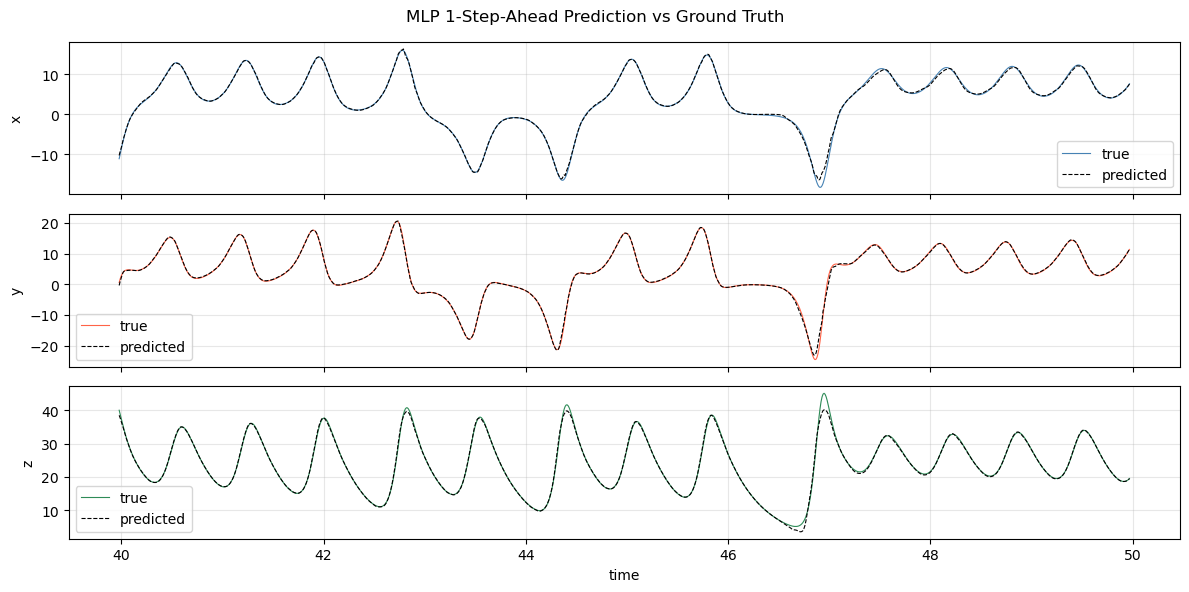

In [13]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test).numpy()  # shape (N_test, 9)

# compare 1-step-ahead prediction vs true next state
true_next  = y_test[:, :3].numpy()    # first predicted step (x, y, z)
pred_next  = pred_test[:, :3]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_test, true_next[:, i], lw=0.8, color=color, label='true')
    axes[i].plot(t_test, pred_next[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('MLP 1-Step-Ahead Prediction vs Ground Truth')
plt.tight_layout()
plt.savefig('nn_prediction.png', dpi=150)
plt.show()


## 2.3. MLP: Result Analysis

The long-term formulation fails completely — the chaotic mapping $t \mapsto (x, y, z)$ 
is too irregular for any network to learn. 
The one-step formulation succeeds locally, 
showing that the short-term dynamics are learnable from data alone. However, without 
any physical grounding, errors accumulate rapidly in autoregressive rollout and the 
trajectory eventually diverges. Performance is good only as long as predictions stay 
close to the training distribution.
Furthermore, by reframing the problem as a linear one, using step-based calculation is not the main idea, just here to show as a reference how MLP predict by regression.

## 3. Neural ODE

Unlike the MLP approach, Neural ODE does not predict the next state directly. 
Instead, it learns the underlying vector field — the rate of change of the system 
at every point in state space:

$$\frac{d\mathbf{u}}{dt} = f_\theta(\mathbf{u})$$

where $f_\theta$ is a neural network. Once this is learned, the trajectory is 
recovered by numerical integration using an ODE solver. This is more principled 
than one-step regression because the network is learning the continuous dynamics 
of the system rather than memorizing discrete transitions.

The key challenge is that training on long sequences is computationally expensive 
and prone to vanishing gradients. Here the model is trained on a short window 
of 50 steps, then evaluated on a much later segment of the trajectory to test 
generalization.

In [14]:
from torchdiffeq import odeint

data = np.load('lorenz_data.npy')
t    = torch.tensor(data[:, 0], dtype=torch.float32)
traj = torch.tensor(data[:, 1:], dtype=torch.float32)

# normalize data
mean = traj.mean(dim=0)
std  = traj.std(dim=0)
traj_norm = (traj - mean) / std


In [15]:
# neural network that learns f(u) = du/dt
class ODEFunc(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64), nn.Tanh(),
            nn.Linear(64, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
    def forward(self, t, u):
        return self.net(u)

start = 2000  # t=20
end   = 2050  # t=20.5


t_train    = t[start:end]
traj_train = traj_norm[start:end]

func      = ODEFunc()
optimizer = torch.optim.Adam(func.parameters(), lr=1e-3)

for epoch in range(3000):
    u_pred = odeint(func, traj_train[0], t_train, method='rk4')
    loss   = nn.MSELoss()(u_pred, traj_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f'epoch {epoch}, loss {loss.item():.4f}')

epoch 0, loss 1.4600
epoch 1, loss 1.2626
epoch 2, loss 1.0864
epoch 3, loss 0.9271
epoch 4, loss 0.7835
epoch 5, loss 0.6557
epoch 6, loss 0.5445
epoch 7, loss 0.4503
epoch 8, loss 0.3727
epoch 9, loss 0.3105
epoch 10, loss 0.2620
epoch 11, loss 0.2249
epoch 12, loss 0.1970
epoch 13, loss 0.1763
epoch 14, loss 0.1610
epoch 15, loss 0.1498
epoch 16, loss 0.1415
epoch 17, loss 0.1353
epoch 18, loss 0.1306
epoch 19, loss 0.1270
epoch 20, loss 0.1243
epoch 21, loss 0.1221
epoch 22, loss 0.1203
epoch 23, loss 0.1189
epoch 24, loss 0.1176
epoch 25, loss 0.1163
epoch 26, loss 0.1151
epoch 27, loss 0.1139
epoch 28, loss 0.1126
epoch 29, loss 0.1111
epoch 30, loss 0.1095
epoch 31, loss 0.1078
epoch 32, loss 0.1058
epoch 33, loss 0.1038
epoch 34, loss 0.1015
epoch 35, loss 0.0992
epoch 36, loss 0.0967
epoch 37, loss 0.0942
epoch 38, loss 0.0917
epoch 39, loss 0.0892
epoch 40, loss 0.0868
epoch 41, loss 0.0844
epoch 42, loss 0.0820
epoch 43, loss 0.0798
epoch 44, loss 0.0777
epoch 45, loss 0.075

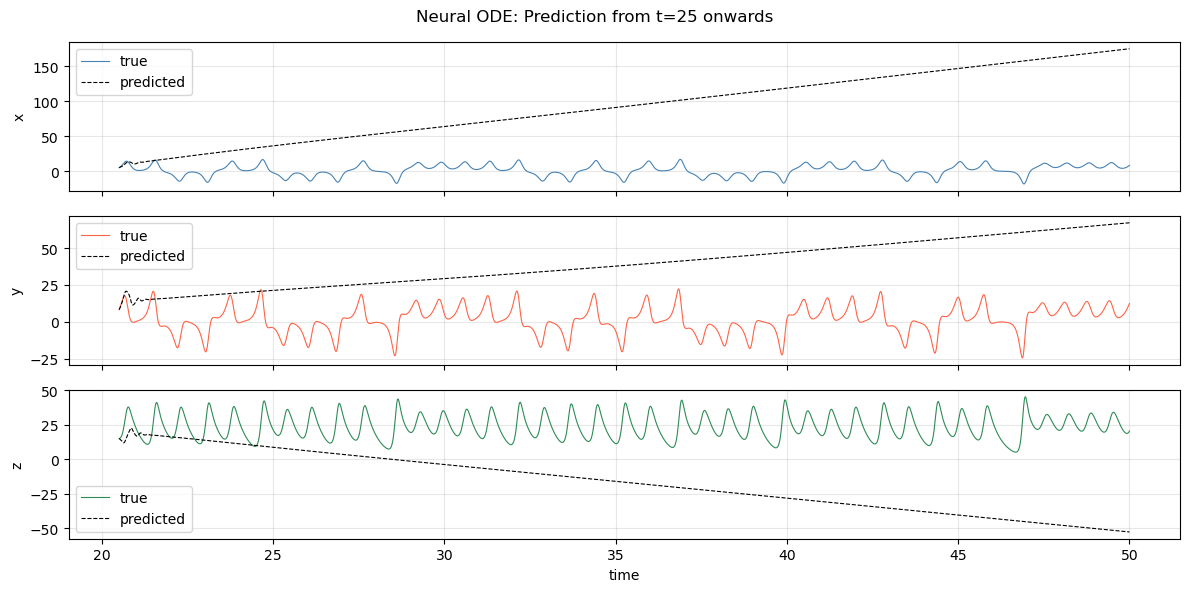

In [16]:
func.eval()
with torch.no_grad():
    # start prediction from t=25 (end of training window)
    u_pred_norm = odeint(func, traj_norm[end], t[end:], method='rk4').numpy()

# denormalize back
u_pred = u_pred_norm * std.numpy() + mean.numpy()
true   = traj[end:].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t[end:], true[:, i],   lw=0.8, color=color, label='true')
    axes[i].plot(t[end:], u_pred[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('Neural ODE: Prediction from t=25 onwards')
plt.tight_layout()
plt.savefig('neural_ode_prediction.png', dpi=150)
plt.show()


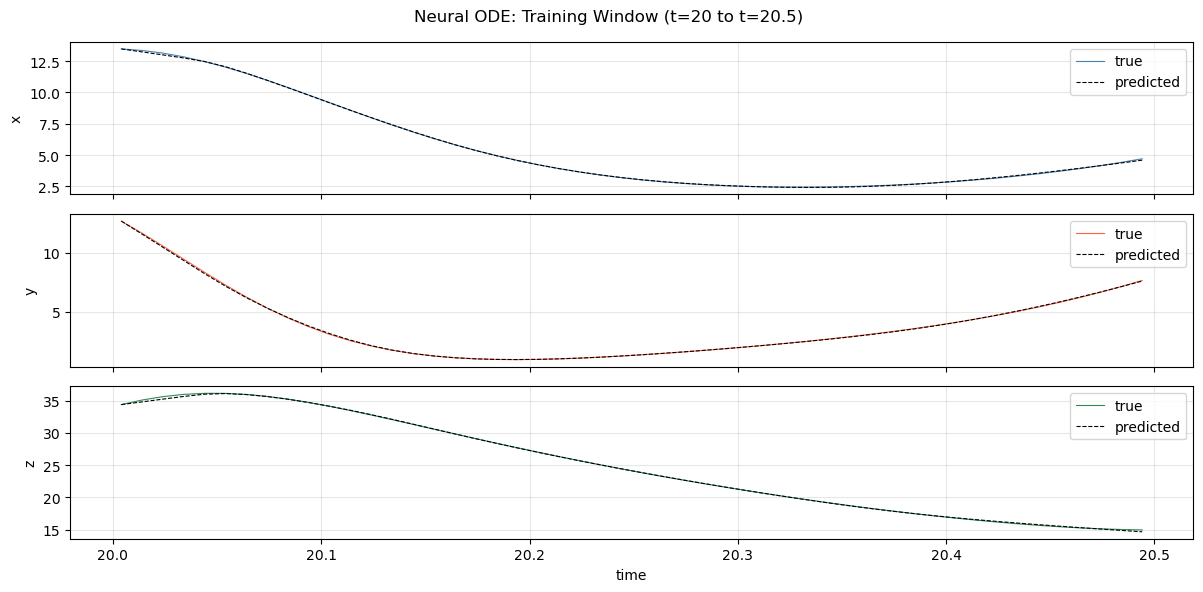

In [17]:
func.eval()
with torch.no_grad():
    u_pred_norm = odeint(func, traj_train[0], t_train, method='rk4').numpy()

u_pred = u_pred_norm * std.numpy() + mean.numpy()
true   = traj[start:end].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_train, true[:, i],   lw=0.8, color=color, label='true')
    axes[i].plot(t_train, u_pred[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('Neural ODE: Training Window (t=20 to t=20.5)')
plt.tight_layout()
plt.savefig('neural_ode_training.png', dpi=150)
plt.show()

## 3.1. Neural ODE: Result Analysis

The model fails to generalize outside the training window. Although it learns 
the local dynamics reasonably well, errors in the learned vector field amplify 
exponentially during integration — a direct consequence of the system's chaotic 
nature. A longer training window and stronger regularization would be needed 
for meaningful improvement.

The above image shows that the Neural ODE did learn something during training, but not good in prediction

## 4. Physics-Informed Neural Network (PINN)

The previous two approaches are purely data-driven — they learn from data alone 
without any knowledge of the underlying physics. PINN takes a different approach 
by embedding the Lorenz equations directly into the training loss.

The network takes time $t$ as input and outputs the state $(x, y, z)$. In addition 
to minimizing the error against the training data, the network is also penalized 
whenever its predictions violate the Lorenz equations. The derivatives $dx/dt$, 
$dy/dt$, $dz/dt$ are computed automatically using `torch.autograd`, so no 
numerical differentiation is needed.

The total loss is:

$$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda \mathcal{L}_{\text{phys}}$$

The goal is to see whether enforcing physical constraints allows the network to 
generalize beyond the training window — something neither the MLP nor Neural ODE 
could achieve.

In [18]:
data = np.load('lorenz_data.npy')
t_all    = torch.tensor(data[:, 0], dtype=torch.float32)
traj_all = torch.tensor(data[:, 1:], dtype=torch.float32)

start = 2000  # t=20
end   = 2050  # t=20.5

t_window = t_all[start:end].unsqueeze(1).requires_grad_(True)
u_window = traj_all[start:end]

# 500 collocation points in [20, 20.5]
t_phys = (torch.rand(500, 1) * 0.5 + 20).requires_grad_(True)

sigma, rho, beta = 10.0, 28.0, 8/3


## 4.1. Using PINN to learn the equation of a small part of the original Lorenz Trajectory

In [19]:
class PINN_Fourier(nn.Module):
    def __init__(self, n_freq=10):
        super().__init__()
        self.n_freq = n_freq
        self.net = nn.Sequential(
            nn.Linear(n_freq * 2, 64), nn.Tanh(),
            nn.Linear(64, 64),         nn.Tanh(),
            nn.Linear(64, 64),         nn.Tanh(),
            nn.Linear(64, 3)
        )
    def fourier(self, t):
        freqs = torch.arange(1, self.n_freq + 1).float()
        return torch.cat([torch.sin(freqs * t), torch.cos(freqs * t)], dim=1)
    def forward(self, t):
        return self.net(self.fourier(t))

model     = PINN_Fourier()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def physics_loss(t):
    u = model(t)
    x, y, z = u[:, 0], u[:, 1], u[:, 2]
    dx = torch.autograd.grad(x.sum(), t, create_graph=True)[0][:, 0]
    dy = torch.autograd.grad(y.sum(), t, create_graph=True)[0][:, 0]
    dz = torch.autograd.grad(z.sum(), t, create_graph=True)[0][:, 0]
    res_x = dx - sigma * (y - x)
    res_y = dy - x * (rho - z) + y
    res_z = dz - x * y + beta * z
    return (res_x**2 + res_y**2 + res_z**2).mean()

for epoch in range(5000):
    optimizer.zero_grad()
    loss_data = nn.MSELoss()(model(t_window), u_window)
    loss_phys = physics_loss(t_phys)
    loss = loss_data + loss_phys
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f'epoch {epoch}, data {loss_data.item():.4f}, phys {loss_phys.item():.4f}')


epoch 0, data 250.5111, phys 7.4483
epoch 1000, data 9.3726, phys 0.8838
epoch 2000, data 2.0062, phys 0.1712
epoch 3000, data 1.2798, phys 0.0515
epoch 4000, data 0.7895, phys 0.1080


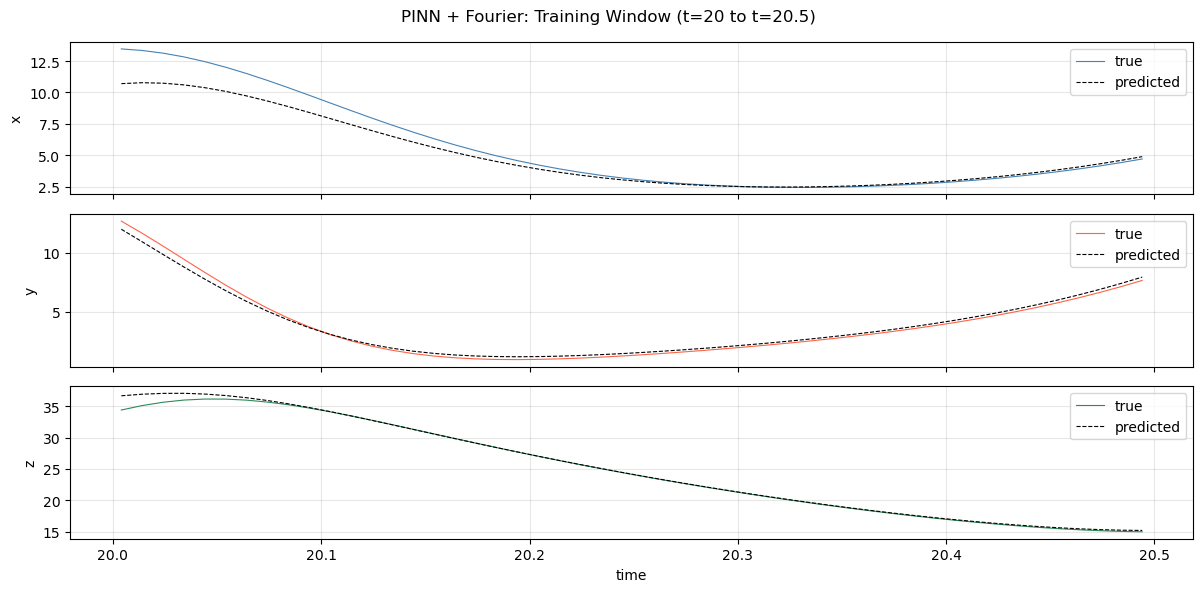

In [20]:
model.eval()
with torch.no_grad():
    t_plot = t_all[start:end].unsqueeze(1)
    u_pred = model(t_plot).numpy()

true = traj_all[start:end].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_all[start:end], true[:, i],   lw=0.8, color=color, label='true')
    axes[i].plot(t_all[start:end], u_pred[:, i], lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('PINN + Fourier: Training Window (t=20 to t=20.5)')
plt.tight_layout()
plt.savefig('pinn_fourier.png', dpi=150)
plt.show()


## 4.2. Data points fitting
This part is using PINN to fit the original data point by memorizing a large scale of original data
Therefore, testing in what kind of way that the method will fit the data will, theoretically, the model will then
use the same method to learn the equation of Lorenz System

In [21]:
# normalize t as well
t_mean = t_all.mean()
t_std  = t_all.std()
t_norm = (t_all - t_mean) / t_std

t_input = t_norm.unsqueeze(1).requires_grad_(True)
u_all_norm = (traj_all - traj_all.mean(dim=0)) / traj_all.std(dim=0)

sigma, rho, beta = 10.0, 28.0, 8/3

In [22]:
model = PINN_Fourier(n_freq=20)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

# stage 1: just fit the data
for epoch in range(5000):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(t_input), u_all_norm)
    loss.backward()
    optimizer.step()
    scheduler.step()
    print(f'epoch {epoch}, loss {loss.item():.4f}')

epoch 0, loss 1.0201
epoch 1, loss 1.0023
epoch 2, loss 0.9860
epoch 3, loss 0.9707
epoch 4, loss 0.9561
epoch 5, loss 0.9417
epoch 6, loss 0.9272
epoch 7, loss 0.9124
epoch 8, loss 0.8970
epoch 9, loss 0.8807
epoch 10, loss 0.8637
epoch 11, loss 0.8460
epoch 12, loss 0.8278
epoch 13, loss 0.8094
epoch 14, loss 0.7915
epoch 15, loss 0.7747
epoch 16, loss 0.7598
epoch 17, loss 0.7478
epoch 18, loss 0.7392
epoch 19, loss 0.7343
epoch 20, loss 0.7328
epoch 21, loss 0.7334
epoch 22, loss 0.7347
epoch 23, loss 0.7354
epoch 24, loss 0.7347
epoch 25, loss 0.7324
epoch 26, loss 0.7291
epoch 27, loss 0.7254
epoch 28, loss 0.7220
epoch 29, loss 0.7192
epoch 30, loss 0.7174
epoch 31, loss 0.7163
epoch 32, loss 0.7158
epoch 33, loss 0.7156
epoch 34, loss 0.7154
epoch 35, loss 0.7150
epoch 36, loss 0.7143
epoch 37, loss 0.7133
epoch 38, loss 0.7120
epoch 39, loss 0.7106
epoch 40, loss 0.7090
epoch 41, loss 0.7075
epoch 42, loss 0.7062
epoch 43, loss 0.7050
epoch 44, loss 0.7040
epoch 45, loss 0.703

In [23]:
t_phys_norm = (torch.rand(5000, 1) * 50 - t_mean.item()) / t_std.item()
t_phys_norm.requires_grad_(True)

optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-4)

def physics_loss_norm(t):
    u = model(t)
    # scale back to original
    u_orig = u * traj_all.std(dim=0) + traj_all.mean(dim=0)
    x, y, z = u_orig[:, 0], u_orig[:, 1], u_orig[:, 2]
    # dt_orig = dt_norm * t_std
    dx = torch.autograd.grad(x.sum(), t, create_graph=True)[0][:, 0] / t_std
    dy = torch.autograd.grad(y.sum(), t, create_graph=True)[0][:, 0] / t_std
    dz = torch.autograd.grad(z.sum(), t, create_graph=True)[0][:, 0] / t_std
    res_x = dx - sigma * (y - x)
    res_y = dy - x * (rho - z) + y
    res_z = dz - x * y + beta * z
    return (res_x**2 + res_y**2 + res_z**2).mean()

for epoch in range(5000):
    optimizer2.zero_grad()
    loss_data = nn.MSELoss()(model(t_input), u_all_norm)
    loss_phys = physics_loss_norm(t_phys_norm)
    loss = loss_data + 0.0001 * loss_phys
    loss.backward()
    optimizer2.step()
    print(f'epoch {epoch}, data {loss_data.item():.4f}, phys {loss_phys.item():.4f}')

epoch 0, data 0.0014, phys 134.5161
epoch 1, data 0.0024, phys 144.9799
epoch 2, data 0.0019, phys 136.5926
epoch 3, data 0.0018, phys 136.2719
epoch 4, data 0.0017, phys 136.0119
epoch 5, data 0.0017, phys 131.9529
epoch 6, data 0.0016, phys 128.7892
epoch 7, data 0.0017, phys 128.4584
epoch 8, data 0.0017, phys 127.4461
epoch 9, data 0.0017, phys 125.7463
epoch 10, data 0.0017, phys 124.6402
epoch 11, data 0.0017, phys 123.9334
epoch 12, data 0.0017, phys 123.1729
epoch 13, data 0.0016, phys 122.6352
epoch 14, data 0.0016, phys 122.2632
epoch 15, data 0.0016, phys 121.5102
epoch 16, data 0.0016, phys 120.4641
epoch 17, data 0.0016, phys 119.5502
epoch 18, data 0.0017, phys 118.9701
epoch 19, data 0.0017, phys 118.6027
epoch 20, data 0.0017, phys 118.0744
epoch 21, data 0.0017, phys 117.2962
epoch 22, data 0.0017, phys 116.5815
epoch 23, data 0.0017, phys 116.2130
epoch 24, data 0.0017, phys 116.0786
epoch 25, data 0.0017, phys 115.7614
epoch 26, data 0.0017, phys 115.1723
epoch 27, d

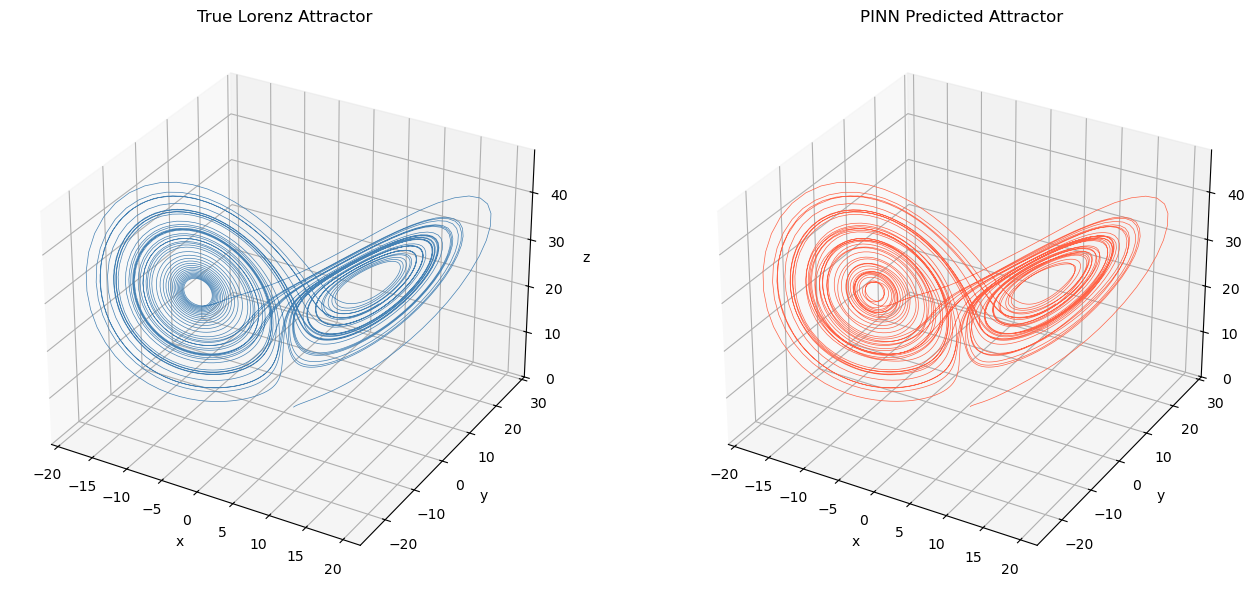

In [24]:
model.eval()
with torch.no_grad():
    u_pred_norm = model(t_norm.unsqueeze(1)).numpy()

u_pred = u_pred_norm * traj_all.std(dim=0).numpy() + traj_all.mean(dim=0).numpy()

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(traj_all[:, 0], traj_all[:, 1], traj_all[:, 2], lw=0.5, color='steelblue')
ax1.set_title('True Lorenz Attractor')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(u_pred[:, 0], u_pred[:, 1], u_pred[:, 2], lw=0.5, color='tomato')
ax2.set_title('PINN Predicted Attractor')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.tight_layout()
plt.savefig('pinn_attractor.png', dpi=150)
plt.show()

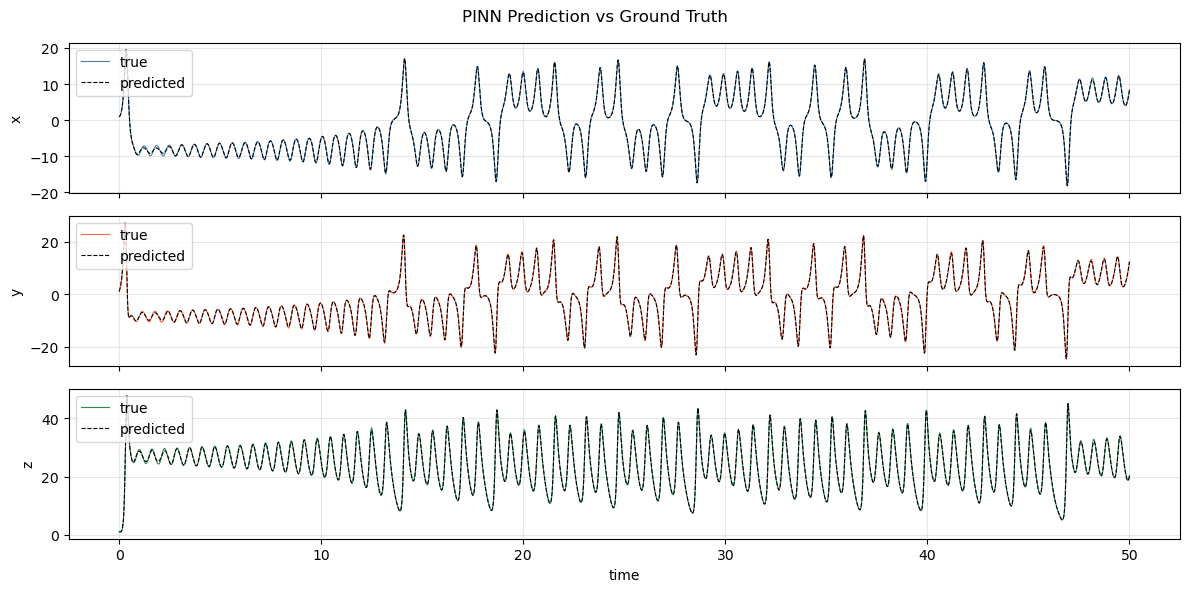

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    axes[i].plot(t_all, traj_all[:, i],  lw=0.8, color=color, label='true')
    axes[i].plot(t_all, u_pred[:, i],    lw=0.8, color='black', linestyle='--', label='predicted')
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel('time')
plt.suptitle('PINN Prediction vs Ground Truth')
plt.tight_layout()
plt.savefig('pinn_xyz.png', dpi=150)
plt.show()

As the images displayed, using a two stage loss, the fitting was perfect, so by analogy, I used the same method on model training for PINN

## 4.3. System Prediction (Two loss combined, but sequentially trained: Data Loss + Physical Loss)

In [26]:
# train on first 1000 points (t=0 to t=10)
train_end = 1000

t_train_raw = t_all[:train_end]
u_train_raw = traj_all[:train_end]

# normalize
t_mean = t_train_raw.mean()
t_std  = t_train_raw.std()
u_mean = u_train_raw.mean(dim=0)
u_std  = u_train_raw.std(dim=0)

t_train_norm = ((t_train_raw - t_mean) / t_std).unsqueeze(1).requires_grad_(True)
u_train_norm = (u_train_raw - u_mean) / u_std

# collocation points only in training window
t_phys_norm = ((torch.rand(2000, 1) * 10) - t_mean) / t_std
t_phys_norm.requires_grad_(True)

sigma, rho, beta = 10.0, 28.0, 8/3

In [27]:
model = PINN_Fourier(n_freq=20)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

for epoch in range(5000):
    optimizer.zero_grad()
    loss = nn.MSELoss()(model(t_train_norm), u_train_norm)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if epoch % 1000 == 0:
        print(f'epoch {epoch}, loss {loss.item():.4f}')

epoch 0, loss 1.0144
epoch 1000, loss 0.0004
epoch 2000, loss 0.0000
epoch 3000, loss 0.0000
epoch 4000, loss 0.0001


In [28]:
optimizer2 = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5000):
    optimizer2.zero_grad()
    loss_data = nn.MSELoss()(model(t_train_norm), u_train_norm)
    loss_phys = physics_loss_norm(t_phys_norm)
    loss = loss_data + 0.0001 * loss_phys
    loss.backward()
    optimizer2.step()
    print(f'epoch {epoch}, data {loss_data.item():.4f}, phys {loss_phys.item():.4f}')

epoch 0, data 0.0000, phys 68182.1797
epoch 1, data 0.0001, phys 66347.6250
epoch 2, data 0.0003, phys 64546.4062
epoch 3, data 0.0006, phys 62779.0039
epoch 4, data 0.0010, phys 61045.9297
epoch 5, data 0.0016, phys 59347.5430
epoch 6, data 0.0023, phys 57684.2656
epoch 7, data 0.0031, phys 56056.3359
epoch 8, data 0.0041, phys 54464.0000
epoch 9, data 0.0051, phys 52907.4141
epoch 10, data 0.0063, phys 51386.7031
epoch 11, data 0.0075, phys 49901.8867
epoch 12, data 0.0089, phys 48452.9609
epoch 13, data 0.0104, phys 47039.8633
epoch 14, data 0.0119, phys 45662.4609
epoch 15, data 0.0136, phys 44320.5859
epoch 16, data 0.0153, phys 43014.0000
epoch 17, data 0.0171, phys 41742.4453
epoch 18, data 0.0190, phys 40505.5938
epoch 19, data 0.0210, phys 39303.0898
epoch 20, data 0.0231, phys 38134.5312
epoch 21, data 0.0252, phys 36999.4648
epoch 22, data 0.0274, phys 35897.4102
epoch 23, data 0.0296, phys 34827.8672
epoch 24, data 0.0319, phys 33790.2773
epoch 25, data 0.0342, phys 32784.0

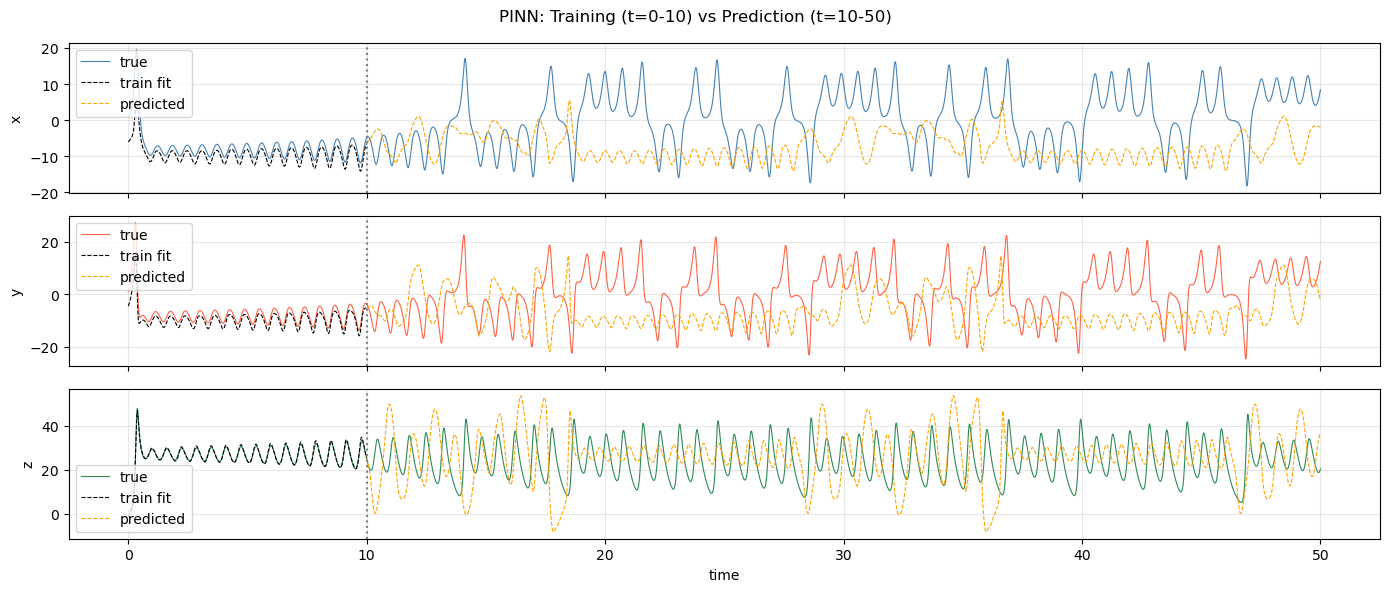

In [29]:
model.eval()
with torch.no_grad():
    # training window
    t_train_plot = ((t_all[:train_end] - t_mean) / t_std).unsqueeze(1)
    u_train_pred = model(t_train_plot).numpy() * u_std.numpy() + u_mean.numpy()

    # prediction window
    t_pred_plot  = ((t_all[train_end:] - t_mean) / t_std).unsqueeze(1)
    u_pred       = model(t_pred_plot).numpy() * u_std.numpy() + u_mean.numpy()

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for i, (label, color) in enumerate(zip(['x','y','z'], ['steelblue','tomato','seagreen'])):
    # true
    axes[i].plot(t_all, traj_all[:, i], lw=0.8, color=color, label='true')
    # training fit
    axes[i].plot(t_all[:train_end], u_train_pred[:, i], lw=0.8, color='black', linestyle='--', label='train fit')
    # prediction
    axes[i].plot(t_all[train_end:], u_pred[:, i], lw=0.8, color='orange', linestyle='--', label='predicted')
    # dividing line
    axes[i].axvline(x=10, color='gray', linestyle=':', lw=1.5)
    axes[i].set_ylabel(label)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('time')
plt.suptitle('PINN: Training (t=0-10) vs Prediction (t=10-50)')
plt.tight_layout()
plt.savefig('pinn_prediction_full.png', dpi=150)
plt.show()

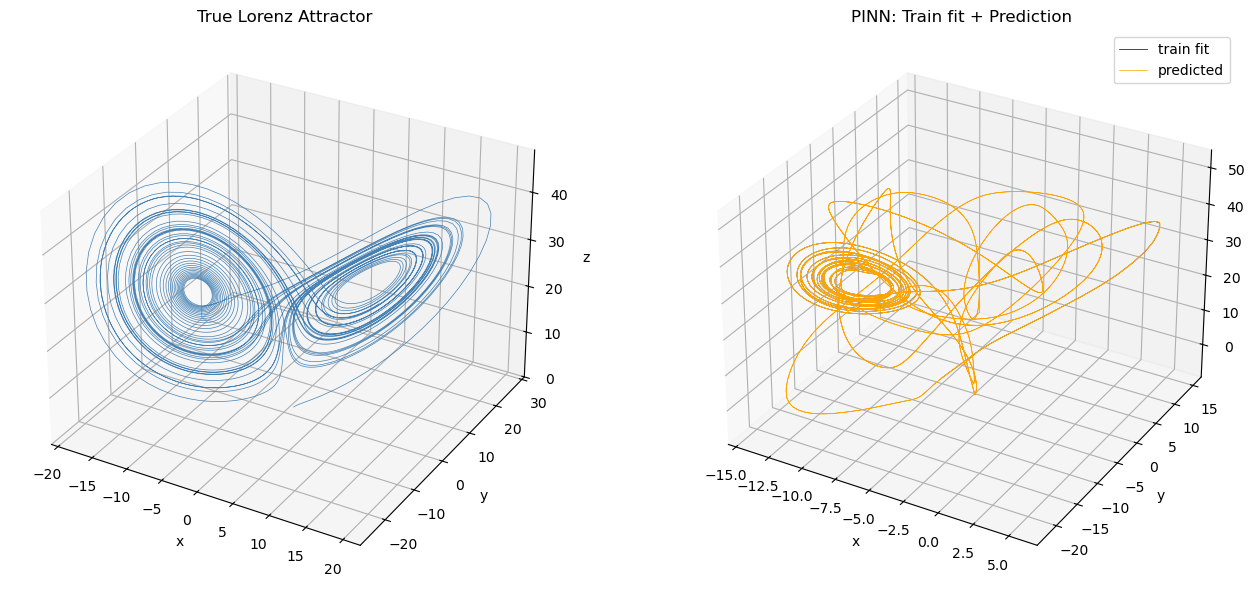

In [30]:
fig = plt.figure(figsize=(14, 6))

# true attractor
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(traj_all[:, 0], traj_all[:, 1], traj_all[:, 2], lw=0.5, color='steelblue')
ax1.set_title('True Lorenz Attractor')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# pinn predicted
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(u_train_pred[:, 0], u_train_pred[:, 1], u_train_pred[:, 2], lw=0.5, color='black', label='train fit')
ax2.plot(u_pred[:, 0],       u_pred[:, 1],       u_pred[:, 2],       lw=0.5, color='orange', label='predicted')
ax2.set_title('PINN: Train fit + Prediction')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')
ax2.legend()

plt.tight_layout()
plt.savefig('pinn_attractor_pred.png', dpi=150)
plt.show()

## 4.4. PINN: Result Analysis

Within the training window, the model fits the trajectory well. Beyond $t = 10$, 
predictions gradually diverge, but the correct oscillation frequency is maintained 
for a short period — evidence that the network has learned something about the 
underlying dynamics, not just memorized the data. Compared to the MLP and Neural 
ODE, PINN produces more structured predictions outside the training range, which 
demonstrates the value of embedding physical constraints into the loss.